In [1]:
from nbodykit.lab import *
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt

import sys
sys.path.append('../general_routines/')
from general_tools import *
from iterative_reconstruction import *

In [2]:
BoxSize = 2000.
Nmesh = 360
zobs = 0.3
zrec = 3.

In [3]:
# Read galaxy catalog and set it as nbodykit catalogs
mass_g = np.load('mass_z0.3_masscut1e12.npy')

pos_g = np.zeros((len(mass_g), 3))

pos_g[:,0] = np.load('posx_z0.3_masscut1e12.npy')
pos_g[:,1] = np.load('posy_z0.3_masscut1e12.npy')
pos_g[:,2] = np.load('posz_z0.3_masscut1e12.npy')

In [4]:
# Convert to catalog
data = numpy.empty(len(mass_g), dtype=[('Position', ('f8', 3)), ('Mass', 'f8')])
data['Position'] = pos_g
data['Mass'] = mass_g

# initialize the catalog
galaxy_cat = ArrayCatalog(data, BoxSize=BoxSize, Nmesh=Nmesh)

In [6]:
delta_g = galaxy_cat.to_mesh(resampler='cic', interlaced=True, compensated=True)

In [7]:
matter_mesh = np.fromfile('dm_field_abacus_rankorder_iterative_z0.3.DAT', dtype=np.float32)
dm_mesh = ArrayMesh(matter_mesh.reshape((Nmesh, Nmesh, Nmesh)), BoxSize=BoxSize, Nmesh=Nmesh)

In [8]:
r = FFTPower(delta_g, mode='1d')
Pkg = r.power['power'].real - r.attrs['shotnoise']
r = FFTPower(dm_mesh, mode='1d')
Pkdm = r.power['power'].real - r.attrs['shotnoise']

In [9]:
peculiar_field = compute_Psi(BoxSize, Nmesh, dm_mesh.compute(mode='real')- 1.)
observer = np.array([BoxSize/2,BoxSize/2,BoxSize/2])
vr = compute_vr(field_interpolation(BoxSize, Nmesh, peculiar_field, galaxy_cat['Position'].compute()), galaxy_cat['Position'].compute(), observer, zobs)
galaxy_cat['PositionRSD'] = boxfit_conditions(galaxy_cat['Position'].compute() + vr, BoxSize)

In [10]:
delta_grsd = galaxy_cat.to_mesh(position='PositionRSD', resampler='cic', interlaced=True, compensated=True)
r = FFTPower(delta_grsd, mode='1d')
Pkgrsd = r.power['power'].real - r.attrs['shotnoise']

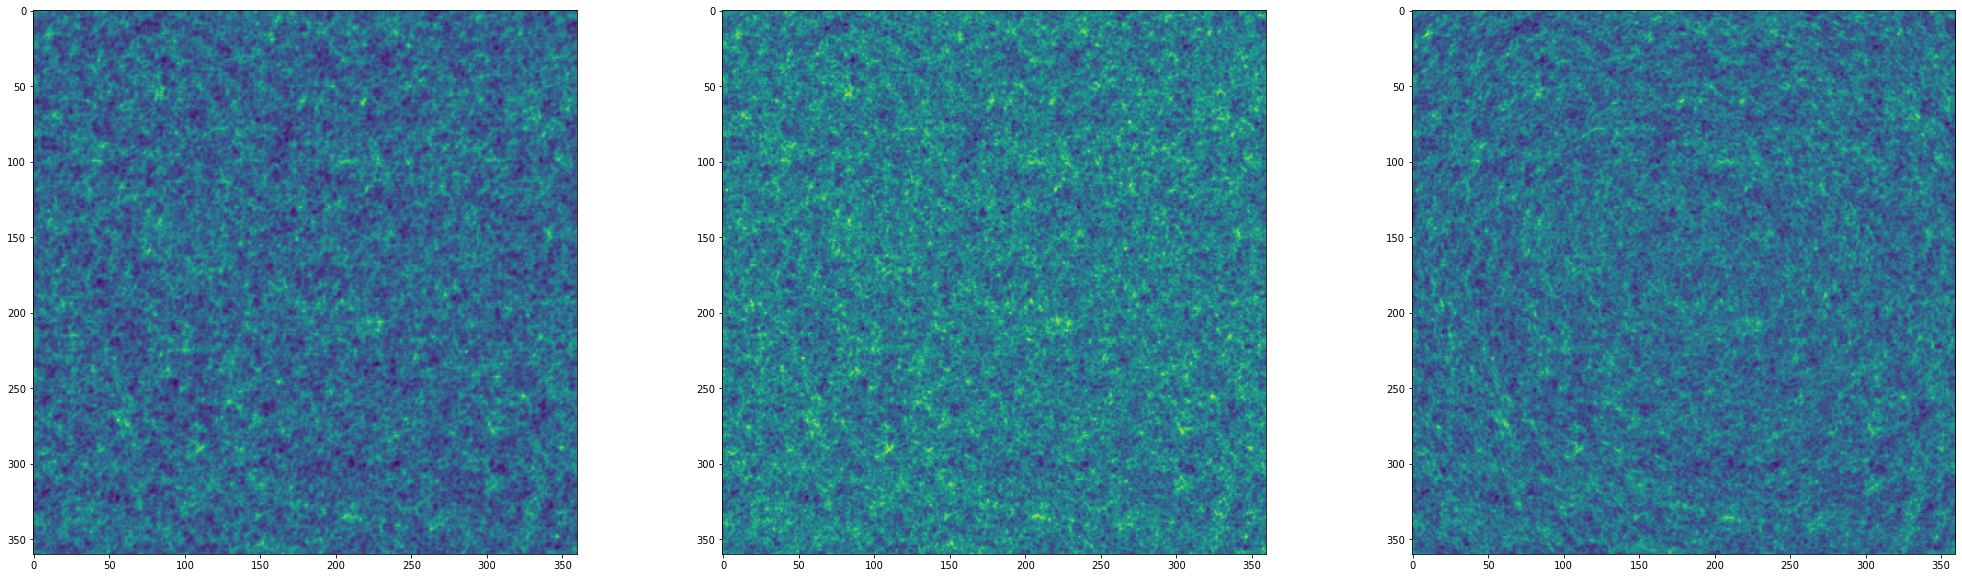

In [11]:
fig, ax = plt.subplots(1,3, figsize=(35,10))
ax[0].imshow(dm_mesh.preview(axes=[0,1]))
ax[1].imshow(delta_g.preview(axes=[0,1]))
ax[2].imshow(delta_grsd.preview(axes=[0,1]))
# for axs in ax:
#     axs.set(xlim=(0,50), ylim=(0,50))

Text(0, 0.5, '$P(k) \\, [\\mathrm{h}^3 \\mathrm{Mpc}^{-3}]$')

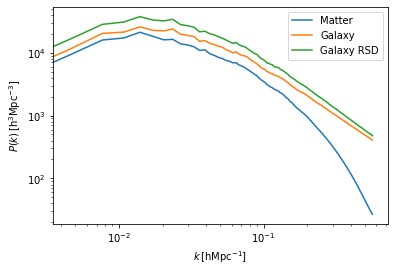

In [12]:
plt.loglog(r.power['k'], Pkdm, label='Matter')
plt.loglog(r.power['k'], Pkg, label='Galaxy')
plt.loglog(r.power['k'], Pkgrsd, label='Galaxy RSD')
plt.legend()
plt.xlabel(r'$k \, [\mathrm{h Mpc}^{-1}]$')
plt.ylabel(r'$P(k) \, [\mathrm{h}^3 \mathrm{Mpc}^{-3}]$')

In [13]:
bgobs, std_bgobs = evaluate_bias(galaxy_cat, dm_mesh, return_std=True)
print('Bias at z=0.3: ', bgobs)

print('Expected bias after reconstruction at z={:.2f}'.format(zrec))
print('From real space: {:.3f}'.format(bgobs))
breczrectr = (bgobs-1)*(D(zobs)/D(zrec)) + 1
breczobstr = (bgobs-1) + (D(zrec)/D(zobs))
print('Bias brec(zinit) = {:.3f}'.format(breczrectr))
print('Bias brec(zobs) = {:.3f}'.format(breczobstr))

Bias at z=0.3:  1.2213819856509511
Expected bias after reconstruction at z=3.00
From real space: 1.221
Bias brec(zinit) = 1.597
Bias brec(zobs) = 0.592


In [14]:
bgobs, std_bgobs = evaluate_bias(galaxy_cat, dm_mesh, tracer_pos='PositionRSD', return_std=True)

In [15]:
r_s = 2.*(BoxSize/Nmesh) # smoothing radius
print('Smoothing radius=', r_s)

print('Expected bias after reconstruction at z={:.2f}'.format(zrec))
print('From redshift space: {:.3f}'.format(bgobs))
breczrectr = (bgobs-1)*(D(zobs)/D(zrec)) + 1
breczobstr = (bgobs-1) + (D(zrec)/D(zobs))

print('Bias brec(zinit) = {:.3f}'.format(breczrectr))
print('Bias brec(zobs) = {:.3f}'.format(breczobstr))

Smoothing radius= 11.11111111111111
Expected bias after reconstruction at z=3.00
From redshift space: 1.447
Bias brec(zinit) = 2.206
Bias brec(zobs) = 0.818


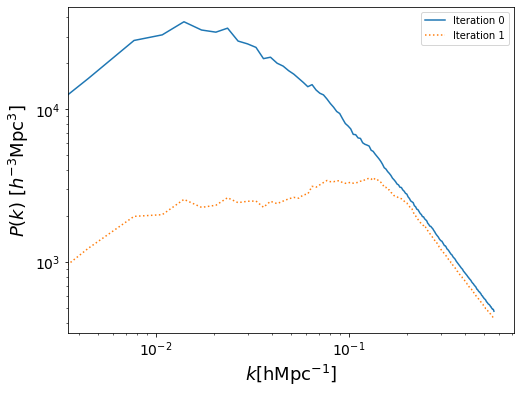

Iteration 1, Mean difference between Pks: 3125.69


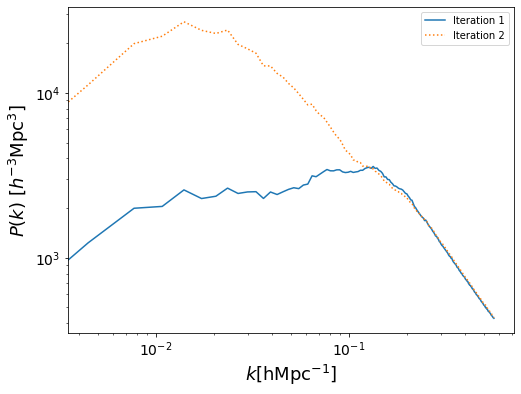

Iteration 2, Mean difference between Pks: 1713.66


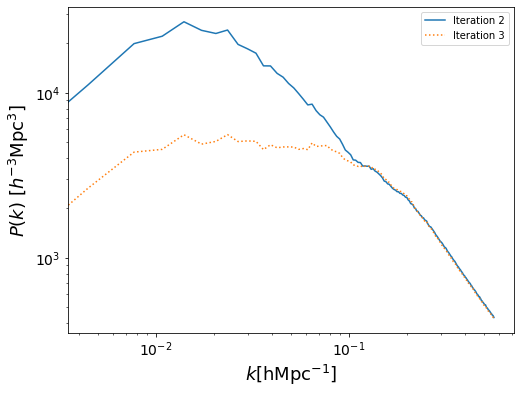

Iteration 3, Mean difference between Pks: 1369.10


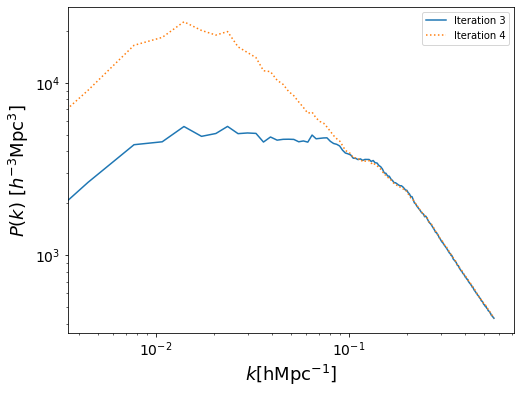

Iteration 4, Mean difference between Pks: 969.92


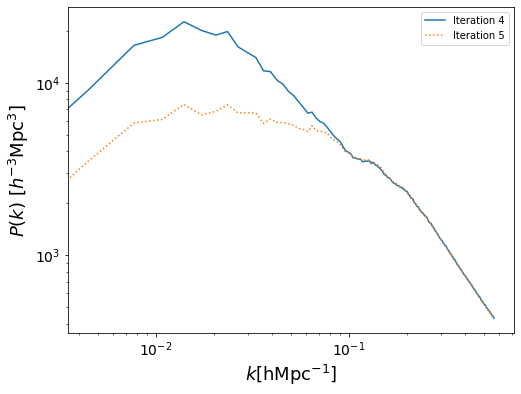

Iteration 5, Mean difference between Pks: 805.82


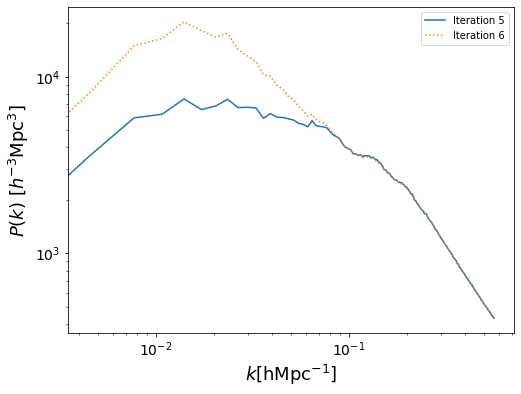

Iteration 6, Mean difference between Pks: 623.96


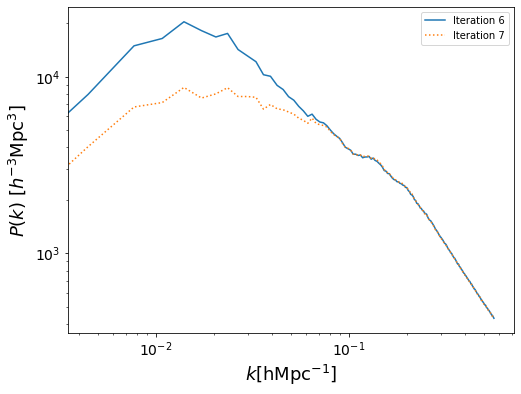

Iteration 7, Mean difference between Pks: 535.43


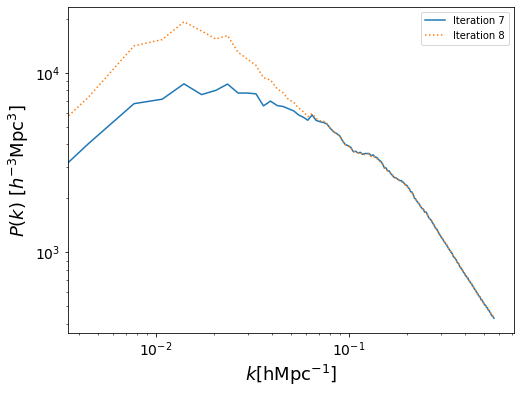

Iteration 8, Mean difference between Pks: 438.45


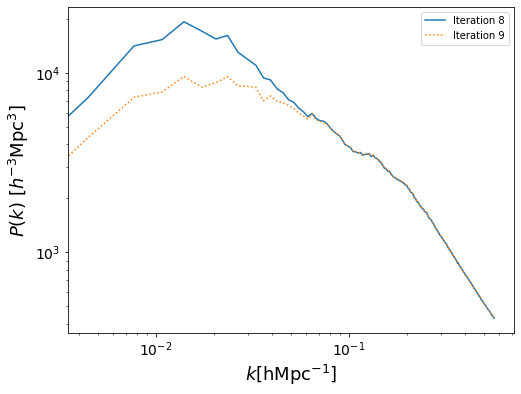

Iteration 9, Mean difference between Pks: 385.11


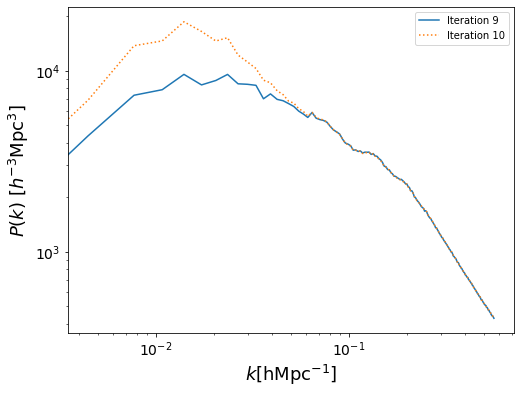

Iteration 10, Mean difference between Pks: 328.04


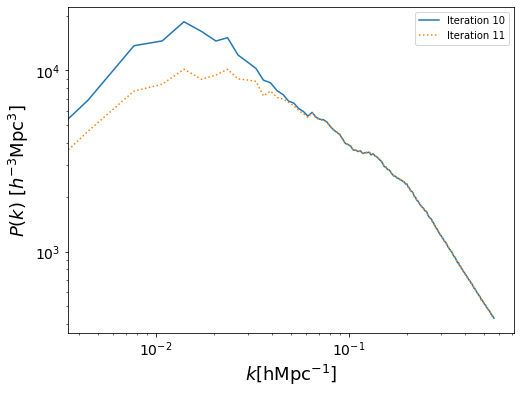

Iteration 11, Mean difference between Pks: 292.66


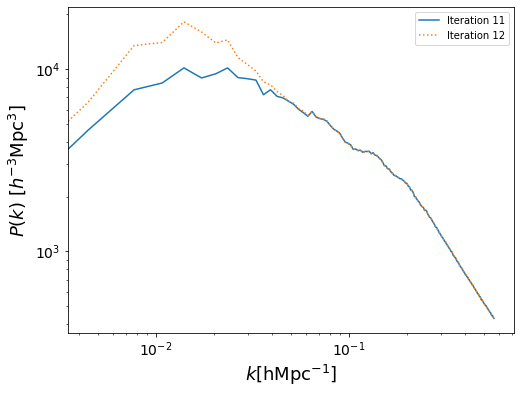

Iteration 12, Mean difference between Pks: 257.79


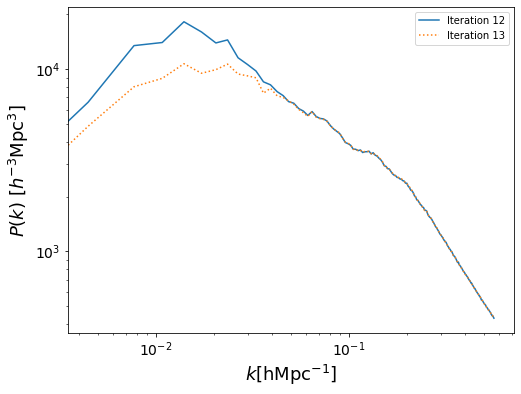

Iteration 13, Mean difference between Pks: 232.49


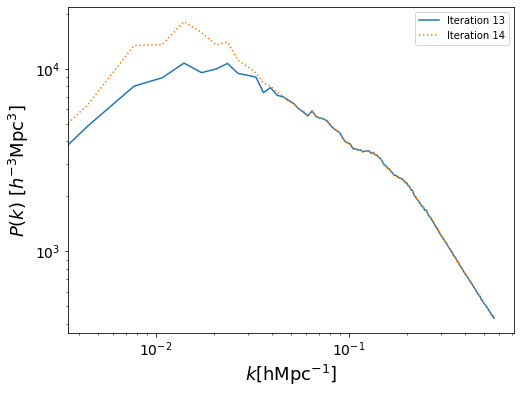

Iteration 14, Mean difference between Pks: 210.59


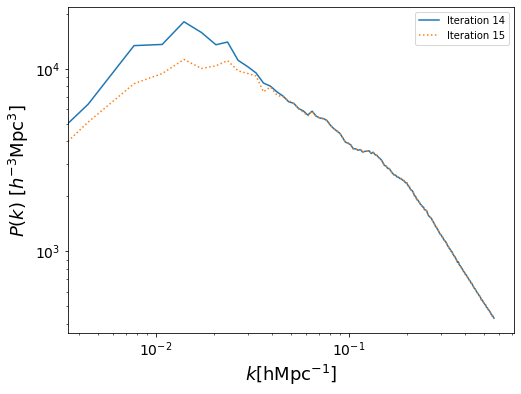

Iteration 15, Mean difference between Pks: 190.44


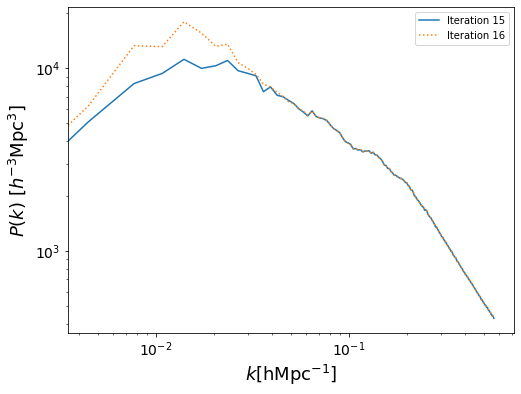

Iteration 16, Mean difference between Pks: 176.75


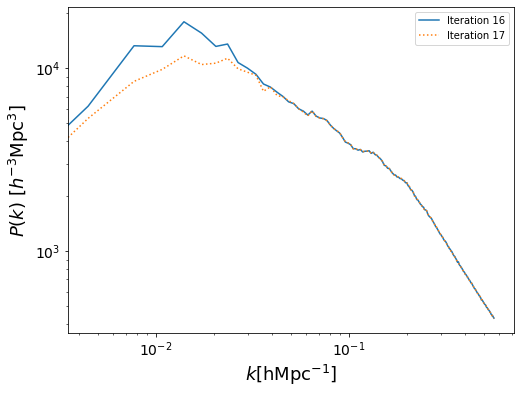

Iteration 17, Mean difference between Pks: 159.66


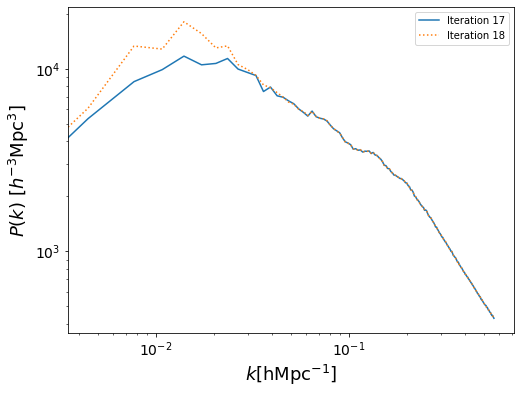

Iteration 18, Mean difference between Pks: 151.78


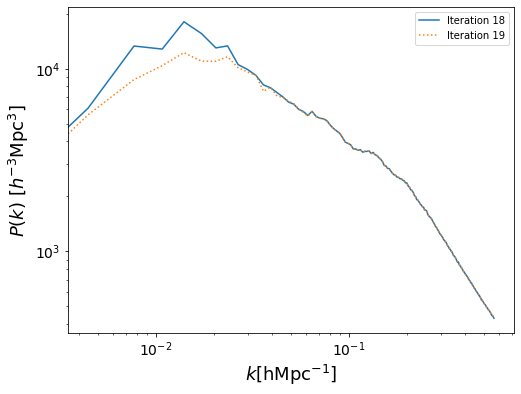

Iteration 19, Mean difference between Pks: 135.91


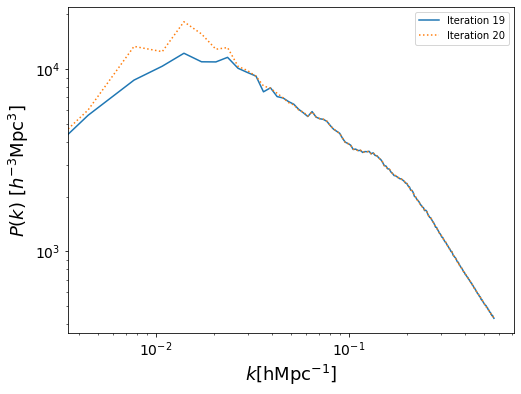

Iteration 20, Mean difference between Pks: 131.82


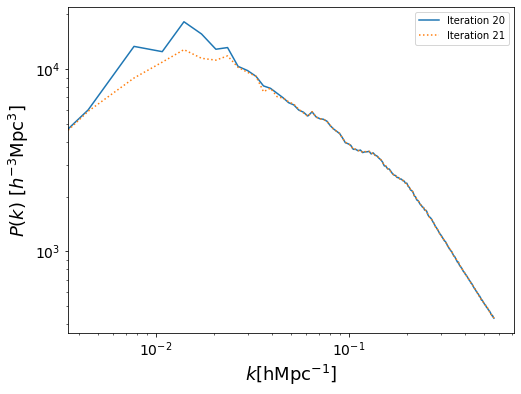

Iteration 21, Mean difference between Pks: 116.06


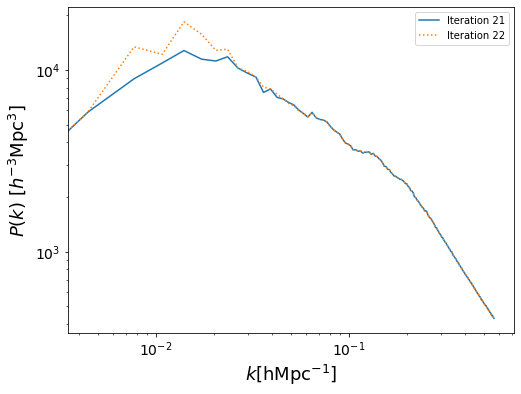

Iteration 22, Mean difference between Pks: 114.67


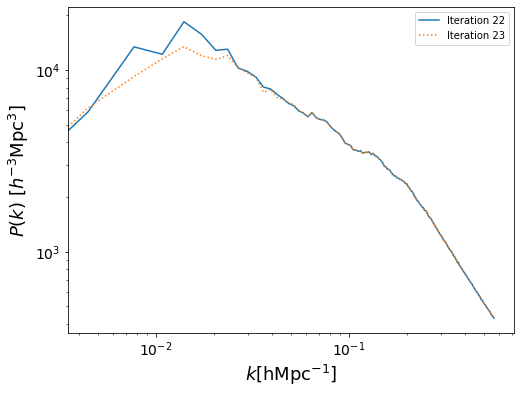

Iteration 23, Mean difference between Pks: 103.52


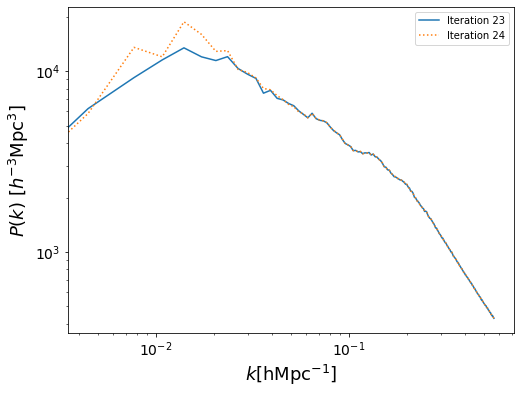

Iteration 24, Mean difference between Pks: 105.94


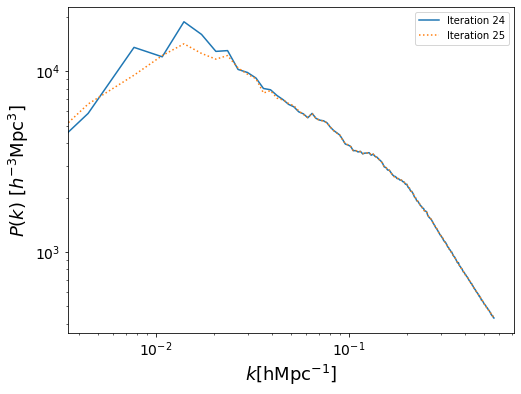

Iteration 25, Mean difference between Pks: 96.56


In [16]:
iterative_reconstruction(25, BoxSize, Nmesh, zobs, zrec, galaxy_cat, dm_mesh,\
                          np.array([BoxSize/2., BoxSize/2., BoxSize/2.]),\
                          redshift_pos='PositionRSD', plot_iterations=True)

In [17]:
print('Bias after reconstruction:')
print('At real space:')
bgrecons2r = evaluate_bias(galaxy_cat, dm_mesh, tracer_pos='PositionQR')
bgrecons1r = bgrecons2r * D(zobs)/D(zrec)
print('bias (redshift) POST= {:.3f}(z={:.2f}),{:.3f}(z={:.2f})'.format(bgrecons1r, zrec,bgrecons2r, zobs))

print('\n')
print('At redshift space:')
# Reconstructed bias
bgrecons2s = evaluate_bias(galaxy_cat, dm_mesh, tracer_pos='PositionQS')
bgrecons1s = bgrecons2s * D(zobs)/D(zrec)
print('bias (redshift) POST= {:.3f}(z={:.2f}),{:.3f}(z={:.2f})'.format(bgrecons1s, zrec,bgrecons2s, zobs))

Bias after reconstruction:
At real space:
bias (redshift) POST= 2.073(z=3.00),0.769(z=0.30)


At redshift space:
bias (redshift) POST= 2.548(z=3.00),0.945(z=0.30)
